In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the data 
df1 = pd.read_excel("Bamaur Project villages_ Fluoride assessment study.xlsx", skiprows=2)
df2 = pd.read_excel("Mirzapur Project villages_ Fluoride assessment study.xlsx", skiprows=2)
df3 = pd.read_excel("Terauli Project villages_ Fluoride assessment study.xlsx", skiprows=2)

#df.concat([df1, df2, df3], ignore_index=True, sort=False)
df = pd.concat([df1, df2, df3])


/tmp/ipykernel_56096/2543786512.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_56096/2543786512.py:12: UserWarning: The palette list has more values (90) than needed (89), which may not be intended.
  sns.barplot(


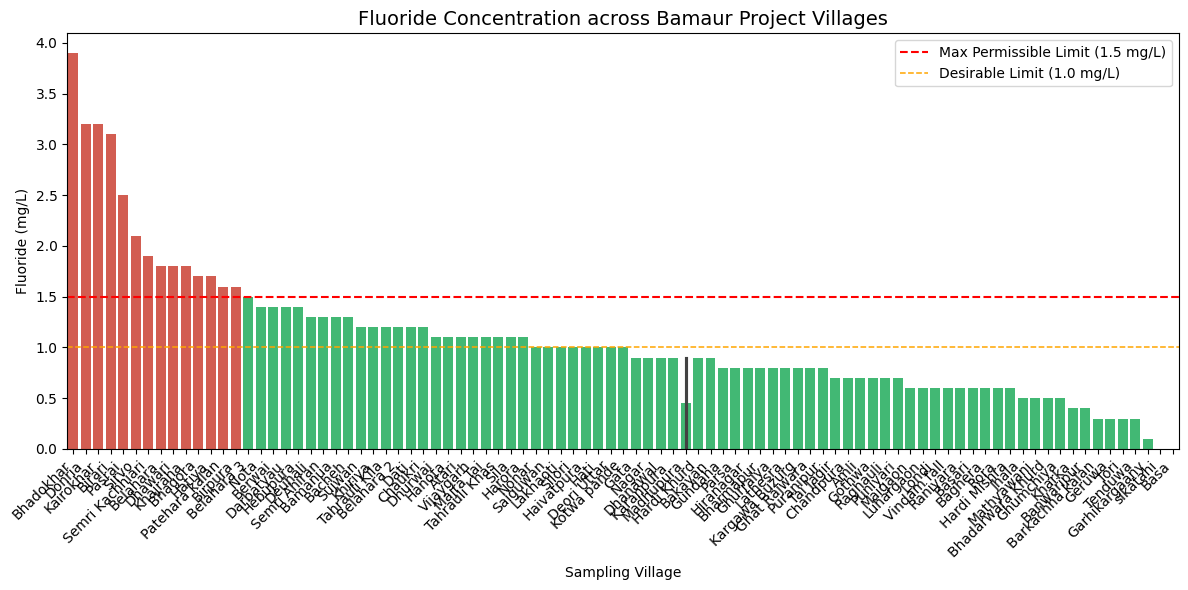

In [2]:
# Clean column names (strip spaces)
df.columns = df.columns.str.strip()

# Sort by Fluoride level for better visualization
df_sorted = df.sort_values(by="Fluoride (mg/L)", ascending=False)

plt.figure(figsize=(12, 6))
colors = [
    "#e74c3c" if x > 1.5 else "#2ecc71" for x in df_sorted["Fluoride (mg/L)"]
]

sns.barplot(
    x="Sampling Village", y="Fluoride (mg/L)", data=df_sorted, palette=colors
)
plt.axhline(
    y=1.5,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Max Permissible Limit (1.5 mg/L)",
)
plt.axhline(
    y=1.0, color="orange", linestyle="--", linewidth=1.1, label="Desirable Limit (1.0 mg/L)"
)

plt.title("Fluoride Concentration across Bamaur Project Villages", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fluoride (mg/L)")
plt.xlabel("Sampling Village")
plt.legend()
plt.tight_layout()
plt.show()

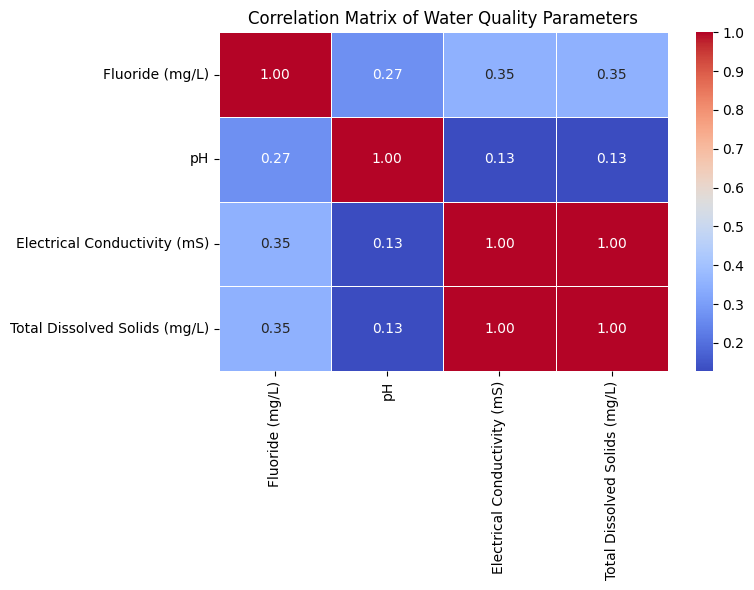

In [3]:
plt.figure(figsize=(8, 6))
numeric_cols = [
    "Fluoride (mg/L)",
    "pH",
    "Electrical Conductivity (mS)",
    "Total Dissolved Solids (mg/L)",
    "Temperature (ºC)",
]
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Water Quality Parameters")
plt.tight_layout()
plt.show()

In [4]:
df

,Unnamed: 0,Sample ID,Sampling Village,Fluoride (mg/L),pH,Electrical Conductivity (mS),Total Dissolved Solids (mg/L),Temperature (ºC),Latitude,Longitude
0,NaN,B1,Kharka,0.4,6.97,1.637,1388.0,29.4,25.680007,79.299700
1,NaN,B2,Hiranagar,0.8,7.10,1.210,1027.0,30.4,25.643879,79.316923
2,NaN,B3,Saiguwan,1.0,7.20,1.151,976.2,28.5,25.637539,79.271998
3,NaN,B4,Kairokhar,3.2,6.96,3.644,3091.0,29.7,25.631760,79.272698
4,NaN,B5,Bacheh,1.3,7.51,0.839,711.8,28.2,25.593747,79.145267
...,...,...,...,...,...,...,...,...,...,...
35,NaN,T36,Sujwan,1.2,7.14,1.050,890.6,29.8,25.466445,79.060133
36,NaN,T37,Tahrauli Khas,1.1,7.70,1.034,876.9,28.5,25.539092,78.992040
37,NaN,T38,Tahrauli Kila,1.2,7.15,1.522,1291.0,28.8,25.534457,79.002436
38,NaN,T39,Tai Jagir,0.7,6.99,1.941,1646.0,28..9,25.496860,79.001497


In [5]:
df.dtypes

Unnamed: 0                       float64
Sample ID                         object
Sampling Village                  object
Fluoride (mg/L)                  float64
pH                               float64
Electrical Conductivity (mS)     float64
Total Dissolved Solids (mg/L)    float64
Temperature (ºC)                  object
Latitude                         float64
Longitude                        float64
dtype: object

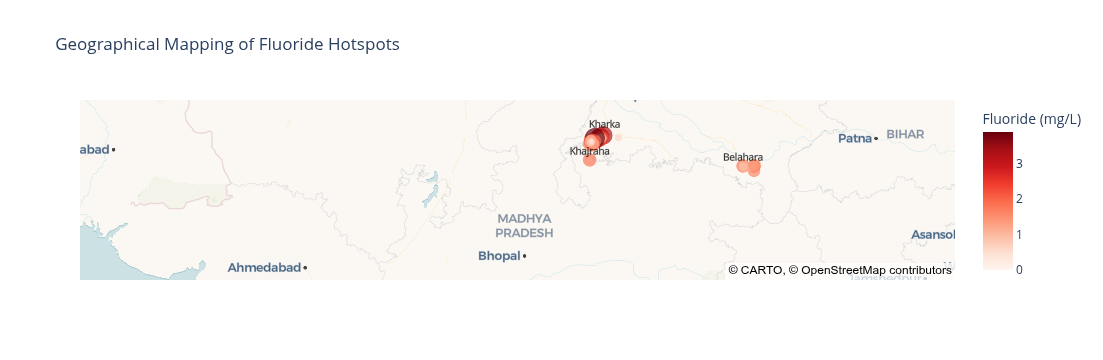

In [8]:
import plotly.express as px

fig = px.scatter_map(
    df,
    lat="Latitude",
    lon="Longitude",
    text="Sampling Village",
    hover_name="Sampling Village",
    hover_data=["Fluoride (mg/L)", "pH", "Total Dissolved Solids (mg/L)"],
    color="Fluoride (mg/L)",
    size="Fluoride (mg/L)",
    color_continuous_scale=px.colors.sequential.Reds,
    size_max=15,
    zoom=5,
    title="Geographical Mapping of Fluoride Hotspots",
)

fig.update_layout(mapbox_style="open-street-map")
#fig.update_traces(mode="markers+text")

fig.update_traces(
    mode="markers+text",
    textposition="top center",  # Pushes text above the marker so it's visible
    textfont=dict(
        size=10,
        color="black"
    )
)


fig.show()

fig.write_html("flouride_map.html")

In [7]:
import plotly.express as px
import plotly.graph_objects as go

# 1. Use the new open-source scatter_map instead of scatter_mapbox
fig = px.scatter_map(
    df,
    lat="Latitude",
    lon="Longitude",
    hover_name="Sampling Village",
    hover_data=["Fluoride (mg/L)", "pH", "Total Dissolved Solids (mg/L)"],
    color="Fluoride (mg/L)",
    size="Fluoride (mg/L)",
    color_continuous_scale=px.colors.sequential.Reds,
    size_max=15,
    zoom=5,
    title="Geographical Mapping of Fluoride Hotspots",
)

# 2. Add the text layer using go.Scattermap (Notice no "box" in the name)
fig.add_trace(
    go.Scattermap(
        lat=df["Latitude"],
        lon=df["Longitude"],
        mode="text",
        text=df["Sampling Village"].astype(str), # Ensure text is strictly strings
        textposition="top right",
        textfont=dict(
            size=11, 
            color="black", 
            family="Arial Black"
        ),
        hoverinfo="skip" 
    )
)

# 3. Apply the layout style
fig.update_layout(
    map_style="open-street-map", # Use map_style instead of mapbox_style
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    showlegend=False
)

fig.show()
fig.write_html("flouride_map.html")